### Week 1 notebook - Polynomial and Interaction Terms, Mod C Data Science Capstone Fall 2026
### By Shuqin Ouyang

# Overall notebook structure:

This week, I will look into concepts including linear regression with polynomial terms, interaction terms, multicollinearity, variance inflation factor and regression, and categorical and continuous features for datasets. And try provide conclusions for below questions:


Considering per technique this week:

- How did you avoid overfitting? What techniques, why expected to help, what were the results?
- What metric(s) did you use, what was the result? Any hyperparameter tuning, and what do those hyperparameters mean?
- What was expected vs. unexpected in the results?
- How did your EDA help shape this week's modeling choices?
- What external source (beyond course materials) did you use? Post it to Yellowdig with a brief note on why it's high-quality, and respond to at least one peer's source.

Considering bigger picture:

- How has this week's work helped address your capstone's research questions (which ratios/behaviors signal risk and in what direction; whether bankruptcy is harder to learn than default; whether results are stable)?
- How do you know your conclusions are true? Ground this in something quantitative, an R squared change, a p-value, an F1 improvement, not just a visual impression, and explain why the finding actually matters.

# Student dataset analysis starts here:

Dataset 1 background quick overview:

The dataset 1 used is the Taiwanese Bankruptcy Prediction dataset from UCI, link as https://archive.ics.uci.edu/dataset/572/taiwanese+bankruptcy+prediction.
It contains company financial indicators and a binary outcome for bankruptcy. It is commonly used for classification tasks to study which financial features are most predictive of financial distress.

In [21]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, OneHotEncoder
from sklearn.metrics import r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

In [22]:
# install uci package so can load the data using package
# install once in terminal or notebook

!pip install ucimlrepo

from ucimlrepo import fetch_ucirepo

# load dataset from UCI repository using dataset id
data_bankruptcy = fetch_ucirepo(id=572)

# UCI dataset already decides features and targets already, but still need to look into details / verify to make sure all ok

# .copy() is used to create an independent copy of the features and target data.
# This ensures that any later changes (e.g., renaming columns, feature engineering, scaling)
# do not affect the original UCI dataset object. It prevents unintended side effects and
# makes the dataframe safe for preprocessing and modeling.
# extract target column (y = output label, such as bankrupt or not)
# combine features and target into one dataframe
# axis=1 means join column wise, side by side

df_bankruptcy = pd.concat(
    [data_bankruptcy.data.features.copy(),
     data_bankruptcy.data.targets.copy()],
    axis=1
)

# remove leading/trailing spaces from column names once, here, so the exact
# names can be used consistently everywhere else in the notebook
df_bankruptcy.columns = df_bankruptcy.columns.str.strip()

# show first 5 rows
df_bankruptcy.head()

'pip' is not recognized as an internal or external command,
operable program or batch file.


,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),Operating Expense Rate,Research and development expense rate,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (B),Net Value Per Share (A),Net Value Per Share (C),Persistent EPS in the Last Four Seasons,Cash Flow Per Share,Revenue Per Share (Yuan ¥),Operating Profit Per Share (Yuan ¥),Per Share Net profit before tax (Yuan ¥),Realized Sales Gross Profit Growth Rate,Operating Profit Growth Rate,After-tax Net Profit Growth Rate,Regular Net Profit Growth Rate,Continuous Net Profit Growth Rate,Total Asset Growth Rate,Net Value Growth Rate,Total Asset Return Growth Rate Ratio,Cash Reinvestment %,Current Ratio,Quick Ratio,Interest Expense Ratio,Total debt/Total net worth,Debt ratio %,Net worth/Assets,Long-term fund suitability ratio (A),Borrowing dependency,Contingent liabilities/Net worth,Operating profit/Paid-in capital,Net profit before tax/Paid-in capital,Inventory and accounts receivable/Net value,Total Asset Turnover,Accounts Receivable Turnover,Average Collection Days,Inventory Turnover Rate (times),Fixed Assets Turnover Frequency,Net Worth Turnover Rate (times),Revenue per person,Operating profit per person,Allocation rate per person,Working Capital to Total Assets,Quick Assets/Total Assets,Current Assets/Total Assets,Cash/Total Assets,Quick Assets/Current Liability,Cash/Current Liability,Current Liability to Assets,Operating Funds to Liability,Inventory/Working Capital,Inventory/Current Liability,Current Liabilities/Liability,Working Capital/Equity,Current Liabilities/Equity,Long-term Liability to Current Assets,Retained Earnings to Total Assets,Total income/Total expense,Total expense/Assets,Current Asset Turnover Rate,Quick Asset Turnover Rate,Working capitcal Turnover Rate,Cash Turnover Rate,Cash Flow to Sales,Fixed Assets to Assets,Current Liability to Liability,Current Liability to Equity,Equity to Long-term Liability,Cash Flow to Total Assets,Cash Flow to Liability,CFO to Assets,Cash Flow to Equity,Current Liability to Current Assets,Liability-Assets Flag,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability,Bankrupt?
0,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,0.780985,1.256969e-04,0.0,0.458143,0.000725,0.0,0.147950,0.147950,0.147950,0.169141,0.311664,0.017560,0.095921,0.138736,0.022102,0.848195,0.688979,0.688979,0.217535,4.980000e+09,0.000327,0.263100,0.363725,0.002259,0.001208,0.629951,0.021266,0.207576,0.792424,0.005024,0.390284,0.006479,0.095885,0.137757,0.398036,0.086957,0.001814,0.003487,1.820926e-04,1.165007e-04,0.032903,0.034164,0.392913,0.037135,0.672775,0.166673,0.190643,0.004094,0.001997,1.473360e-04,0.147308,0.334015,0.276920,0.001036,0.676269,0.721275,0.339077,0.025592,0.903225,0.002022,0.064856,7.010000e+08,6.550000e+09,0.593831,4.580000e+08,0.671568,0.424206,0.676269,0.339077,0.126549,0.637555,0.458609,0.520382,0.312905,0.118250,0,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469,1
1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,0.781506,2.897851e-04,0.0,0.461867,0.000647,0.0,0.182251,0.182251,0.182251,0.208944,0.318137,0.021144,0.093722,0.169918,0.022080,0.848088,0.689693,0.689702,0.217620,6.110000e+09,0.000443,0.264516,0.376709,0.006016,0.004039,0.635172,0.012502,0.171176,0.828824,0.005059,0.376760,0.005835,0.093743,0.168962,0.397725,0.064468,0.001286,0.004917,9.360000e+09,7.190000e+08,0.025484,0.006889

In [23]:
# show dataset info
df_bankruptcy.info()

<class 'pandas.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   ROA(C) before interest and depreciation before interest  6819 non-null   float64
 1   ROA(A) before interest and % after tax                   6819 non-null   float64
 2   ROA(B) before interest and depreciation after tax        6819 non-null   float64
 3   Operating Gross Margin                                   6819 non-null   float64
 4   Realized Sales Gross Margin                              6819 non-null   float64
 5   Operating Profit Rate                                    6819 non-null   float64
 6   Pre-tax net Interest Rate                                6819 non-null   float64
 7   After-tax net Interest Rate                              6819 non-null   float64
 8   Non-industry income and expenditure/rev

In [24]:
# show dataset summary stats
# show all columns describe data and no truncation
pd.set_option('display.max_columns', None)
# optional: also show all rows (careful, can be huge)
pd.set_option('display.max_rows', None)

df_bankruptcy.describe()

,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),Operating Expense Rate,Research and development expense rate,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (B),Net Value Per Share (A),Net Value Per Share (C),Persistent EPS in the Last Four Seasons,Cash Flow Per Share,Revenue Per Share (Yuan ¥),Operating Profit Per Share (Yuan ¥),Per Share Net profit before tax (Yuan ¥),Realized Sales Gross Profit Growth Rate,Operating Profit Growth Rate,After-tax Net Profit Growth Rate,Regular Net Profit Growth Rate,Continuous Net Profit Growth Rate,Total Asset Growth Rate,Net Value Growth Rate,Total Asset Return Growth Rate Ratio,Cash Reinvestment %,Current Ratio,Quick Ratio,Interest Expense Ratio,Total debt/Total net worth,Debt ratio %,Net worth/Assets,Long-term fund suitability ratio (A),Borrowing dependency,Contingent liabilities/Net worth,Operating profit/Paid-in capital,Net profit before tax/Paid-in capital,Inventory and accounts receivable/Net value,Total Asset Turnover,Accounts Receivable Turnover,Average Collection Days,Inventory Turnover Rate (times),Fixed Assets Turnover Frequency,Net Worth Turnover Rate (times),Revenue per person,Operating profit per person,Allocation rate per person,Working Capital to Total Assets,Quick Assets/Total Assets,Current Assets/Total Assets,Cash/Total Assets,Quick Assets/Current Liability,Cash/Current Liability,Current Liability to Assets,Operating Funds to Liability,Inventory/Working Capital,Inventory/Current Liability,Current Liabilities/Liability,Working Capital/Equity,Current Liabilities/Equity,Long-term Liability to Current Assets,Retained Earnings to Total Assets,Total income/Total expense,Total expense/Assets,Current Asset Turnover Rate,Quick Asset Turnover Rate,Working capitcal Turnover Rate,Cash Turnover Rate,Cash Flow to Sales,Fixed Assets to Assets,Current Liability to Liability,Current Liability to Equity,Equity to Long-term Liability,Cash Flow to Total Assets,Cash Flow to Liability,CFO to Assets,Cash Flow to Equity,Current Liability to Current Assets,Liability-Assets Flag,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability,Bankrupt?
count,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6.819000e+03,6.819000e+03,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6.819000e+03,6.819000e+03,6819.000000,6819.000000,6.819000e+03,6.819000e+03,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6.819000e+03,6.819000e+03,6.819000e+03,6.819000e+03,6819.000000,6.819000e+03,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6.819000e+03,6.819000e+03,6819.000000,6819.000000,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6.819000e+03,6.819000e+03,6819.000000,6.819000e+03,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.0,6819.000000,6819.000000
mean,0.505180,0.558625,0.553589,0.607948,0.607929,0.998755,0.797190,0.809084,0.303623,0.781381,1.995347e+09,1.950427e+09,0.467431,1.644801e+07,0.115001,0.19

                               x_mid  bankruptcy_rate  count
Net Income to Total Assets                                  
(-0.001, 0.1]               0.000000         0.000000      1
(0.2, 0.3]                  0.224792         0.000000      1
(0.4, 0.5]                  0.438385         0.750000      8
(0.5, 0.6]                  0.549612         0.647059     17
(0.6, 0.7]                  0.665754         0.291667     72
(0.7, 0.8]                  0.777359         0.079326   2017
(0.8, 0.9]                  0.824064         0.004715   4666
(0.9, 1.0]                  0.921426         0.000000     37
Linear R squared: 0.0020467395957963763
Polynomial R squared: 0.602429947337584


c:\Users\ouyan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
c:\Users\ouyan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


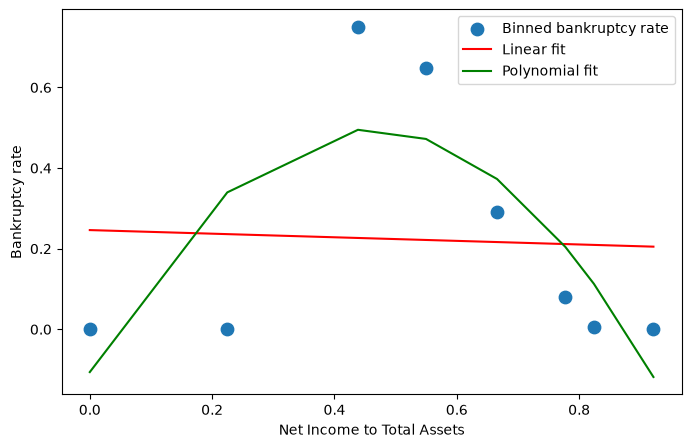

In [25]:
target_bankrupt = 'Bankrupt?'
feature_bankrupt = 'Net Income to Total Assets'

# split the feature into 10 ranges (buckets), since target is 0/1 and needs
# to become a continuous rate before linear regression can work on it
bins_bankrupt = pd.cut(df_bankruptcy[feature_bankrupt], bins=10)

# for each bucket: average feature value, bankruptcy rate (proportion bankrupt), and company count
binned_bankrupt = df_bankruptcy.groupby(bins_bankrupt, observed=True).agg(
    x_mid=(feature_bankrupt, 'mean'),
    bankruptcy_rate=(target_bankrupt, 'mean'),
    count=(target_bankrupt, 'count')
).dropna()

print(binned_bankrupt)

# X = bucket's average feature value, y = bucket's bankruptcy rate (this is now continuous)
X_bankrupt = binned_bankrupt[['x_mid']]
y_bankrupt = binned_bankrupt['bankruptcy_rate']

# fit a straight line first, as the baseline to compare against
lin_model_bankrupt = LinearRegression().fit(X_bankrupt, y_bankrupt)
r_squared_linear_bankrupt = r2_score(y_bankrupt, lin_model_bankrupt.predict(X_bankrupt))

# add a squared version of the feature as a second column, still using the
# same LinearRegression tool, just letting it fit a curve instead of a line
# (include_bias=False since LinearRegression adds its own intercept already)
poly_bankrupt = PolynomialFeatures(degree=2, include_bias=False)
X_poly_bankrupt = poly_bankrupt.fit_transform(X_bankrupt)
poly_model_bankrupt = LinearRegression().fit(X_poly_bankrupt, y_bankrupt)
r_squared_poly_bankrupt = r2_score(y_bankrupt, poly_model_bankrupt.predict(X_poly_bankrupt))

print("Linear R squared:", r_squared_linear_bankrupt)
print("Polynomial R squared:", r_squared_poly_bankrupt)

# sort X first so the line plots smoothly left to right instead of zigzagging
X_sorted_bankrupt = np.sort(X_bankrupt.values, axis=0)
X_sorted_poly_bankrupt = poly_bankrupt.transform(X_sorted_bankrupt)

plt.figure(figsize=(8, 5))
plt.scatter(X_bankrupt, y_bankrupt, s=80, label='Binned bankruptcy rate')
plt.plot(X_sorted_bankrupt, lin_model_bankrupt.predict(X_sorted_bankrupt), color='red', label='Linear fit')
plt.plot(X_sorted_bankrupt, poly_model_bankrupt.predict(X_sorted_poly_bankrupt), color='green', label='Polynomial fit')
plt.xlabel(feature_bankrupt)
plt.ylabel('Bankruptcy rate')
plt.legend()
plt.savefig('week1_poly_bankrupt_feature1.png', dpi=150)
plt.show()

In [26]:
degrees_to_test_bankrupt = list(range(1, 11))
results_bankrupt = []

for d in degrees_to_test_bankrupt:
    poly_test = PolynomialFeatures(degree=d, include_bias=False)
    X_poly_test = poly_test.fit_transform(X_bankrupt)
    model_test = LinearRegression().fit(X_poly_test, y_bankrupt)
    r_squared_test = r2_score(y_bankrupt, model_test.predict(X_poly_test))
    results_bankrupt.append((d, r_squared_test))

results_df_bankrupt = pd.DataFrame(results_bankrupt, columns=['Degree', 'R squared'])
print(results_df_bankrupt.to_string(index=False))

# flag the point where R squared starts looking suspiciously perfect
print("\nDegrees with R squared >= 0.999 (likely overfitting given only",
      len(X_bankrupt), "data points):")
print(results_df_bankrupt[results_df_bankrupt['R squared'] >= 0.999])

 Degree  R squared
      1   0.002047
      2   0.602430
      3   0.611254
      4   0.966964
      5   0.998545
      6   0.998668
      7   1.000000
      8   1.000000
      9   1.000000
     10   1.000000

Degrees with R squared >= 0.999 (likely overfitting given only 8 data points):
   Degree  R squared
6       7        1.0
7       8        1.0
8       9        1.0
9      10        1.0


Student markdown:

Since the bankruptcy target is a 0/1 categorical variable, plain linear regression on the raw target isn't appropriate. To work around this, I binned Net Income to Total Assets, chosen because it was my strongest individually-correlated feature with bankruptcy in Module B, into 10 groups and computed the bankruptcy rate within each bin, giving a continuous target.

Polynomial regression isn't a separate tool from linear regression, it's the same underlying model, just given an extra input column. A degree-2 polynomial fits an equation of the form Bankruptcy rate = (coefficient A) × Feature + (coefficient B) × Feature squared, adding a squared version of the feature as a second column lets the same linear regression tool bend into a curve instead of only drawing a straight line, since Feature squared grows faster than Feature itself as values increase.

A linear fit (degree 1) barely explains any variation (R squared = 0.002), while a degree-2 polynomial captures a real, substantial improvement (R squared = 0.602), confirming the relationship is genuinely non-linear. Testing higher degrees shows R squared climbing rapidly to a perfect 1.0000 by degree 7, which, with only 10 data points, reflects the polynomial simply memorizing every point rather than capturing a real pattern, a clear sign of overfitting. Degree 2 is therefore the appropriate choice: it captures the genuine curvature in the data without chasing an artificially perfect fit.

In [27]:
# X and X squared collinearity check
# create the squared version of the feature to test alongside the original
X_poly_vif_bankruptcy = df_bankruptcy[['Net Income to Total Assets']].dropna().copy()
X_poly_vif_bankruptcy['NI/TA squared'] = X_poly_vif_bankruptcy['Net Income to Total Assets'] ** 2

# adds the intercept column (a column of 1s) that VIF's math requires,
# since statsmodels doesn't add this automatically
X_c_bankruptcy = sm.add_constant(X_poly_vif_bankruptcy)

# for each column, checks how well it's predicted from the other columns
# combined; a high VIF (e.g. >5) means it's mostly redundant with the others
vif_poly_bankruptcy = pd.DataFrame({
    'Feature': X_c_bankruptcy.columns,
    'VIF': [variance_inflation_factor(X_c_bankruptcy.values, i) for i in range(X_c_bankruptcy.shape[1])]
})
print(vif_poly_bankruptcy)
print()

cols = ['Current Assets/Total Assets', 'Cash/Total Assets', 'Quick Assets/Total Assets']
data = df_bankruptcy[cols].dropna()

# how well can Current Assets be explained by the other two?
r_sq = sm.OLS(data[cols[0]], sm.add_constant(data[cols[1:]])).fit().rsquared
print("R squared:", r_sq)

# VIF for all three together
X = sm.add_constant(data)
print(pd.DataFrame({'Feature': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]}))

                      Feature        VIF
0                       const   1.000000
1  Net Income to Total Assets  42.174611
2               NI/TA squared  42.174611

R squared: 0.5720890724544667
                       Feature       VIF
0                        const  1.000000
1  Current Assets/Total Assets  2.336935
2            Cash/Total Assets  1.541410
3    Quick Assets/Total Assets  2.967953


Student markdown:

I tested two multicollinearity scenarios using VIF, which measures how much a feature overlaps with the others by checking how well it's predicted from them combined, a high VIF means mostly redundant. First, following the lesson's example of a narrow-range feature making X and X squared collinear, I checked Net Income to Total Assets against its own squared term, since polynomial regression is just linear regression given an extra column (coefficient A times Feature plus coefficient B times Feature squared) to let it curve instead of stay straight. Both came back with the same VIF of 42.2, basically redundant. The polynomial's overall curve (R squared = 0.602) is still trustworthy, but the two individual coefficients aren't, since when features move almost identically, the model can't split credit between them, like two people pushing the same box, you know it moved but not how much force each contributed.

Second, I tested whether Current Assets/Total Assets could be explained by Cash/Total Assets and Quick Assets/Total Assets combined, since Cash sits inside Quick Assets, which sits inside Current Assets by definition. This gave R squared = 0.57 and VIF between 1.5 and 3.0, well below the threshold of 5, real but partial overlap, Current Assets isn't just the other two added together since it also includes things like inventory neither captures.

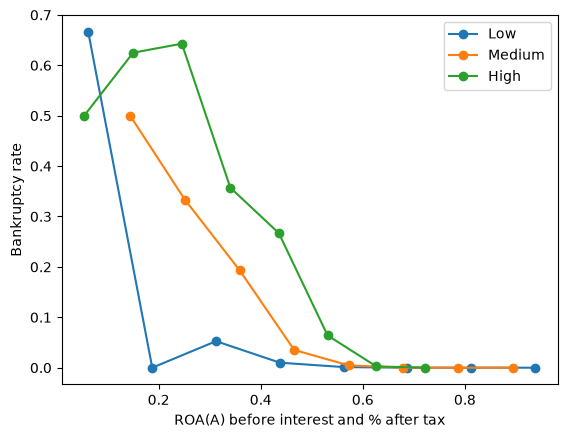

In [28]:
# split companies into Low, Medium, High debt groups, since the lesson's
# approach visualizes an interaction as one line per value of the second variable
roa_col_bankrupt = 'ROA(A) before interest and % after tax'
debt_col_bankrupt = 'Debt ratio %'

df_viz_bankrupt = df_bankruptcy[[roa_col_bankrupt, debt_col_bankrupt, target_bankrupt]].dropna().copy()
df_viz_bankrupt['group'] = pd.qcut(df_viz_bankrupt[debt_col_bankrupt], q=3, labels=['Low', 'Medium', 'High'])

low_bankrupt = df_viz_bankrupt[df_viz_bankrupt['group'] == 'Low']
medium_bankrupt = df_viz_bankrupt[df_viz_bankrupt['group'] == 'Medium']
high_bankrupt = df_viz_bankrupt[df_viz_bankrupt['group'] == 'High']

# for each debt group, bin ROA and compute bankruptcy rate per bin, then plot
# one line per group; different slopes or heights across the lines show the interaction
for name, data in [('Low', low_bankrupt), ('Medium', medium_bankrupt), ('High', high_bankrupt)]:
    binned = pd.cut(data[roa_col_bankrupt], bins=8)
    rate = data.groupby(binned, observed=True)[target_bankrupt].mean()
    x_vals = [b.mid for b in rate.index]
    plt.plot(x_vals, rate.values, marker='o', label=name)

plt.xlabel(roa_col_bankrupt)
plt.ylabel('Bankruptcy rate')
plt.legend()
plt.savefig('week1_interaction_binned.png', dpi=150)
plt.show()

Student markdown:

I wanted to understand interaction terms, which test whether one feature's effect depends on a second feature, so I chose ROA and Debt ratio since they measure different things, profitability and leverage, and there's a real question behind them: does profit protect a company from bankruptcy the same way regardless of debt level.

Splitting companies into Low, Medium, and High debt groups and plotting bankruptcy rate against ROA showed something more interesting than expected. Higher ROA generally means lower bankruptcy rate across all groups, but the shapes aren't parallel. At very low ROA, the Low Debt group surprisingly shows a higher bankruptcy rate than High Debt. Then the High Debt group's bankruptcy rate actually rises as ROA goes from 0 to about 0.4, the opposite of what I'd expect, before dropping back down at higher ROA. This non-parallel, non-monotonic pattern is a clear sign debt level changes how ROA relates to bankruptcy, exactly what an interaction is supposed to show, stronger evidence than the groups just sitting at different heights.

Student markdown:

The bankruptcy dataset is entirely continuous financial ratios, no categorical columns like industry or region exist, except for the categorical target variable, so one-hot encoding doesn't apply here.

**Student markdown:**

Conclusion:

**Overfitting:** For the polynomial term, I limited the degree to 2 rather than testing arbitrarily high powers, and confirmed this was the right call by comparing degrees 1 through 10, R squared rose meaningfully from 0.002 (linear) to 0.602 (degree 2), but climbed to a suspicious 1.0000 by degree 7, which, with only 10 binned data points, reflects the model memorizing every point rather than capturing a real pattern. Degree 2 was the point where genuine curvature was captured without chasing that artificial perfect fit.

**Metrics and results:** I used R squared to compare linear vs polynomial fits (0.002 to 0.602 for Net Income to Total Assets) and VIF to detect multicollinearity. For the interaction between ROA and Debt ratio, I focused on visualizing bankruptcy rate against ROA across Low, Medium, and High debt groups rather than interpreting the interaction coefficient directly, since the actual relationship turned out to be non-monotonic, a shape a single slope-change number wouldn't capture well anyway. No formal hyperparameter tuning was performed, degree was chosen from the degree-comparison test rather than cross-validation, and I used a default of 10 bins without extensively tuning that either.

**Expected vs unexpected:** I actually expected Net Income to Total Assets to fit better with a simple straight line, but R squared of 0.002 was basically nothing, and a degree-2 curve was needed to see the real pattern. I also expected more degrees to keep helping, more flexibility usually meaning more gain, but that wasn't true either, degree 2 was where real improvement stopped and overfitting began. The VIF result between Net Income to Total Assets and its own squared term was expected, since a ratio and its square being closely related made sense to me, especially given how small the values are. The Current Assets test (checking whether it could be explained by combining Cash and Quick Assets) was more moderate than I expected, VIF of 2.3-3.0, not the extreme redundancy I half-anticipated given how much these ratios share in accounting terms. What was genuinely unexpected was the ROA and Debt ratio interaction, I knew one metric can sometimes shift how another behaves, but seeing the High Debt group's bankruptcy rate rise instead of fall at low to moderate ROA was a bigger, stranger effect than I anticipated.

**EDA usefulness:** I chose Net Income to Total Assets for the polynomial test because earlier EDA already showed it highly correlated with the bankruptcy target. For VIF, I noticed in earlier EDA that Debt ratio % and Net worth/Assets had a near-perfect negative correlation, which made me wonder whether asset-based ratios in general might share overlapping information, so I hand-picked a few other asset-related metrics (Current Assets, Cash, Quick Assets, all over Total Assets) to test together, and found a real but moderate overlap rather than a severe one. Without that earlier correlation work, I would have had no real starting point for deciding which features were even worth testing for redundancy, rather than guessing across all 95 columns.

**Sources:** GeeksforGeeks, "Detecting Multicollinearity with VIF - Python" (https://www.geeksforgeeks.org/python/detecting-multicollinearity-with-vif-python/), a clear walkthrough of implementing VIF in Python using statsmodels, explaining that VIF is derived from each feature's R squared when regressed against the others, chosen because it directly matched the exact VIF approach I used this week to test multicollinearity across both the polynomial term and the multi-feature scenarios.

**Bigger picture, research questions:** This week shows Net Income to Total Assets still matters a lot for predicting bankruptcy, but only once fit with the right degree, a plain linear fit barely picks up any signal, while the right polynomial degree captures a real, chartable pattern. At the same time, VIF is a signal to be careful with, ratios like Net Income to Total Assets tend to have small, tightly bounded values, and even a good-fitting polynomial's individual coefficients need this kind of redundancy check before being trusted, plain linear regression may not be the right tool on its own, something Module B's weaker correlation and F1 results for bankruptcy already pointed toward, and it likely means other relationships in this data will need more than a straight line to capture properly. This connects to a bigger need going forward, to keep checking data stability while trying to predict the target, not just chase a good-looking fit. VIF specifically is useful because it surfaces relationships between features that correlation alone can't fully show, and it's worth running across more pairs of similarly-defined metrics going forward, both to catch redundancy and to start noticing which ratios, or combinations of ratios, actually carry unique signal. Lastly, the interaction term ties into this same bigger research goal, since understanding which variables influence each other can eventually help tell the story of what actually drives bankruptcy, and knowing when a relationship between two variables is stable versus unstable will matter for deciding which features are worth keeping in a model built to actually predict well. Overall, this week opened up a way of seeing relationships among variables that correlation alone can't reveal, and it's a reminder to stay mindful of where plain linear regression helps and where it doesn't.

**How I know the conclusions are true:** I'm not just going off what the charts look like, both findings are backed by real numbers. For the polynomial fit, R squared jumped from 0.002 to 0.602, a real, measurable improvement. For the interaction, the pattern across the three debt groups wasn't random, it was a clear, consistent shape, Low Debt behaving one way, High Debt actually rising instead of falling at low to moderate ROA before dropping again, a shape that doesn't happen by accident if debt really had no effect. This matters going forward because a plain, simple model would completely miss both patterns, it would treat Net Income to Total Assets as moving one steady direction, and treat ROA the same for every company regardless of debt, when the riskiest, most confusing cases, high debt with only moderate profit, are exactly where the real risk pattern turned out to be least obvious.

Dataset 2 background quick overview:

The dataset 2 used is the Default of Credit Card Clients dataset from UCI, link as https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients.

It contains demographic information, credit limits, repayment history, bill statements, and previous payment records for Taiwanese credit card clients, along with a binary outcome indicating whether the client defaulted on the next payment. The dataset is commonly used for classification tasks to study how financial behavior and repayment patterns relate to consumer credit risk and default prediction.

In [29]:
# UCI dataset already decides features and targets already, but still need to look into details / verify to make sure all ok
data_credit = fetch_ucirepo(id=350)

df_credit = pd.concat(
    [data_credit.data.features.copy(),
     data_credit.data.targets.copy()],
    axis=1
)

# show 5 rows
df_credit.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [30]:
# columns rename for easier reading

df_credit = df_credit.rename(columns={

    "Y": "default_next_month",

    "X1": "credit_limit",
    "X2": "gender",
    "X3": "education",
    "X4": "marital_status",
    "X5": "age",

    "X6": "repay_2005_sep",
    "X7": "repay_2005_aug",
    "X8": "repay_2005_jul",
    "X9": "repay_2005_jun",
    "X10": "repay_2005_may",
    "X11": "repay_2005_apr",

    "X12": "bill_2005_sep",
    "X13": "bill_2005_aug",
    "X14": "bill_2005_jul",
    "X15": "bill_2005_jun",
    "X16": "bill_2005_may",
    "X17": "bill_2005_apr",

    "X18": "pay_2005_sep",
    "X19": "pay_2005_aug",
    "X20": "pay_2005_jul",
    "X21": "pay_2005_jun",
    "X22": "pay_2005_may",
    "X23": "pay_2005_apr"
})

df_credit.head()

,credit_limit,gender,education,marital_status,age,repay_2005_sep,repay_2005_aug,repay_2005_jul,repay_2005_jun,repay_2005_may,repay_2005_apr,bill_2005_sep,bill_2005_aug,bill_2005_jul,bill_2005_jun,bill_2005_may,bill_2005_apr,pay_2005_sep,pay_2005_aug,pay_2005_jul,pay_2005_jun,pay_2005_may,pay_2005_apr,default_next_month
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [31]:
# show dataset info
df_credit.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   credit_limit        30000 non-null  int64
 1   gender              30000 non-null  int64
 2   education           30000 non-null  int64
 3   marital_status      30000 non-null  int64
 4   age                 30000 non-null  int64
 5   repay_2005_sep      30000 non-null  int64
 6   repay_2005_aug      30000 non-null  int64
 7   repay_2005_jul      30000 non-null  int64
 8   repay_2005_jun      30000 non-null  int64
 9   repay_2005_may      30000 non-null  int64
 10  repay_2005_apr      30000 non-null  int64
 11  bill_2005_sep       30000 non-null  int64
 12  bill_2005_aug       30000 non-null  int64
 13  bill_2005_jul       30000 non-null  int64
 14  bill_2005_jun       30000 non-null  int64
 15  bill_2005_may       30000 non-null  int64
 16  bill_2005_apr       30000 non-null  int64
 17  pay_

In [32]:
# show dataset summary stats
# show all columns describe data and no truncation
pd.set_option('display.max_columns', None)
# optional: also show all rows (careful, can be huge)
pd.set_option('display.max_rows', None)

df_credit.describe()

,credit_limit,gender,education,marital_status,age,repay_2005_sep,repay_2005_aug,repay_2005_jul,repay_2005_jun,repay_2005_may,repay_2005_apr,bill_2005_sep,bill_2005_aug,bill_2005_jul,bill_2005_jun,bill_2005_may,bill_2005_apr,pay_2005_sep,pay_2005_aug,pay_2005_jul,pay_2005_jun,pay_2005_may,pay_2005_apr,default_next_month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,-0.291100,51223.330900,49179.075167,4.701315e+04,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,1.149988,73635.860576,71173.768783,6.934939e+04,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,3558.750000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67091.000000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


                   x_mid  default_rate  count
repay_2005_sep                               
(-2.01, -1.0]  -1.326702      0.156187   8445
(-1.0, 0.0]     0.000000      0.128113  14737
(0.0, 1.0]      1.000000      0.339479   3688
(1.0, 2.0]      2.000000      0.691414   2667
(2.0, 3.0]      3.000000      0.757764    322
(3.0, 4.0]      4.000000      0.684211     76
(4.0, 5.0]      5.000000      0.500000     26
(5.0, 6.0]      6.000000      0.545455     11
(6.0, 7.0]      7.000000      0.777778      9
(7.0, 8.0]      8.000000      0.578947     19
Linear R squared: 0.46822470272173633
Polynomial R squared: 0.6857928456788425


c:\Users\ouyan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
c:\Users\ouyan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


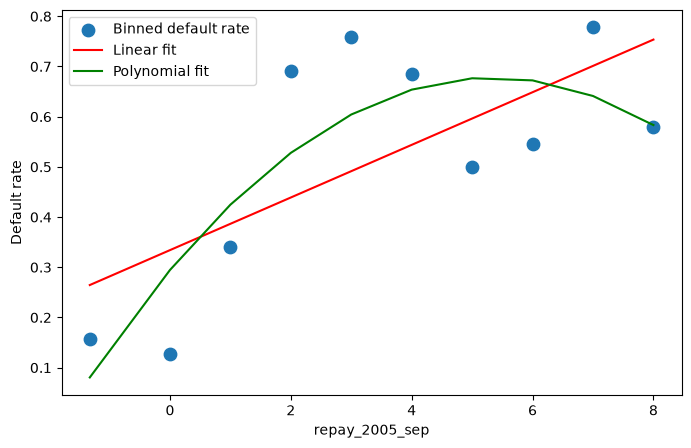

In [33]:
target_credit = 'default_next_month'
feature_credit = 'repay_2005_sep'

# split the feature into 10 ranges (buckets), since the target is 0/1 and needs
# to become a continuous rate before linear regression can work on it
bins_credit = pd.cut(df_credit[feature_credit], bins=10)

# for each bucket: average feature value, default rate (proportion defaulted), and count
binned_credit = df_credit.groupby(bins_credit, observed=True).agg(
    x_mid=(feature_credit, 'mean'),
    default_rate=(target_credit, 'mean'),
    count=(target_credit, 'count')
).dropna()

print(binned_credit)

# X = bucket's average feature value, y = bucket's default rate (now continuous)
X_credit = binned_credit[['x_mid']]
y_credit = binned_credit['default_rate']

# fit a straight line first, as the baseline to compare against
lin_model_credit = LinearRegression().fit(X_credit, y_credit)
r_squared_linear_credit = r2_score(y_credit, lin_model_credit.predict(X_credit))

# add a squared version of the feature as a second column, same LinearRegression
# tool, just letting it fit a curve instead of a straight line
poly_credit = PolynomialFeatures(degree=2, include_bias=False)
X_poly_credit = poly_credit.fit_transform(X_credit)
poly_model_credit = LinearRegression().fit(X_poly_credit, y_credit)
r_squared_poly_credit = r2_score(y_credit, poly_model_credit.predict(X_poly_credit))

print("Linear R squared:", r_squared_linear_credit)
print("Polynomial R squared:", r_squared_poly_credit)

# sort X first so the line plots smoothly left to right instead of zigzagging
X_sorted_credit = np.sort(X_credit.values, axis=0)
X_sorted_poly_credit = poly_credit.transform(X_sorted_credit)

plt.figure(figsize=(8, 5))
plt.scatter(X_credit, y_credit, s=80, label='Binned default rate')
plt.plot(X_sorted_credit, lin_model_credit.predict(X_sorted_credit), color='red', label='Linear fit')
plt.plot(X_sorted_credit, poly_model_credit.predict(X_sorted_poly_credit), color='green', label='Polynomial fit')
plt.xlabel(feature_credit)
plt.ylabel('Default rate')
plt.legend()
plt.savefig('week1_poly_credit.png', dpi=150)
plt.show()

In [34]:
# test degrees 1 through 10 to see where real improvement stops and
# overfitting begins, same overfitting check used for the bankruptcy dataset
degrees_to_test_credit = list(range(1, 11))
results_credit = []
for d in degrees_to_test_credit:
    poly_test = PolynomialFeatures(degree=d, include_bias=False)
    X_poly_test = poly_test.fit_transform(X_credit)
    model_test = LinearRegression().fit(X_poly_test, y_credit)
    r_squared_test = r2_score(y_credit, model_test.predict(X_poly_test))
    results_credit.append((d, r_squared_test))

print(pd.DataFrame(results_credit, columns=['Degree', 'R squared']))

   Degree  R squared
0       1   0.468225
1       2   0.685793
2       3   0.688404
3       4   0.759923
4       5   0.949899
5       6   0.995102
6       7   0.894260
7       8   0.623095
8       9   0.451632
9      10   0.356805


Student markdown:

I chose repayment status for this test because Module B's correlation analysis had already flagged it as meaningfully related to default, so it was a natural first feature to check for curvature. A plain straight line already explains 46.8% of the variation in default rate (R squared = 0.468), a decent amount, since later repayment intuitively signals more risk. Adding a squared term raises this to 68.6% (R squared = 0.686), showing the real relationship curves rather than moving in a perfectly straight line.

Testing degrees 1 through 10 showed something interesting: R squared kept climbing through degree 6 (reaching 0.995), then actually collapsed to 0.357 by degree 10, instead of staying artificially perfect the way bankruptcy's did. This happened because some bins, especially at high repayment values, contained very few companies (as few as 9 to 26). Picture trying to draw a smooth curve through 10 dots where a couple are isolated far off to one side with barely any neighbors nearby, a highly flexible curve tries to swing sharply toward those sparse dots to touch them closely, then swings back the other way to reach the next one. That wild swinging, rather than a smooth, sensible trend, is exactly the "large wiggles" the course reading warns about, and here it became so extreme that it actually made the model's predictions worse overall, not just artificially perfect, like overcorrecting a car's steering so hard you swerve off the road entirely rather than just avoiding a pothole. This confirms degree 2 as the right choice, it captures the genuine curve in the data without chasing unstable, meaningless flexibility in the sparse regions.

In [35]:
# X and X squared collinearity check, same specific scenario from the lesson
# tested for bankruptcy: does the feature's squared version end up collinear
# with the original when the feature has a narrow range?
X_poly_vif_credit = df_credit[['repay_2005_sep']].dropna().copy()
X_poly_vif_credit['repay_squared'] = X_poly_vif_credit['repay_2005_sep'] ** 2

X_c_credit = sm.add_constant(X_poly_vif_credit)
vif_poly_credit = pd.DataFrame({
    'Feature': X_c_credit.columns,
    'VIF': [variance_inflation_factor(X_c_credit.values, i) for i in range(X_c_credit.shape[1])]
})
print(vif_poly_credit)
print()

# testing bill amount across three consecutive months, since Module B's
# correlation analysis found adjacent months above 0.9, a much stronger
# flag than anything used above; testing three at once (not just two) lets
# us see if redundancy compounds the way it did for the bankruptcy ratios
bill_features_credit = ['bill_2005_sep', 'bill_2005_aug', 'bill_2005_jul']
X_bill_credit = sm.add_constant(df_credit[bill_features_credit].dropna())

vif_bill_credit = pd.DataFrame({
    'Feature': X_bill_credit.columns,
    'VIF': [variance_inflation_factor(X_bill_credit.values, i) for i in range(X_bill_credit.shape[1])]
})
print(vif_bill_credit)

          Feature       VIF
0           const  1.000000
1  repay_2005_sep  1.117847
2   repay_squared  1.117847

         Feature        VIF
0          const   1.000000
1  bill_2005_sep  10.627682
2  bill_2005_aug  15.674197
3  bill_2005_jul   7.280326


Student markdown:

I chose repayment status and bill amount since they're logically related, a customer's bill and whether they pay on time are two sides of the same account behavior, and Module B's correlation analysis already flagged bill amounts across months as highly correlated (above 0.9 for adjacent months), since balances naturally carry over.

I expected repayment status to show less collinearity with its own squared term than bankruptcy's Net Income to Total Assets did, since it's a wider, discrete scale (-1 to 8) rather than a narrow continuous ratio, and that held, VIF came back around 1.12, essentially no concern, versus bankruptcy's 42.2.

Testing bill amount across three consecutive months (September, August, July) told a very different story, VIF values of 10.6, 15.7, and 7.3, all well above the threshold of 5. This directly confirms what Module B's correlation analysis already suggested, a customer's bill amount genuinely doesn't change much from month to month, so these three columns are carrying substantially overlapping information rather than independent signal. August, sitting in the middle of the three months, showed the highest VIF (15.7), which makes sense, it can be predicted from both the month before and the month after, while September and July each only have one neighboring month to draw on.

In [ ]:
limit_credit = 'credit_limit'

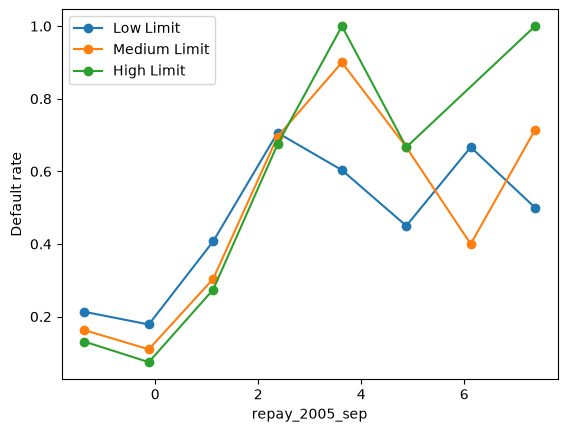

In [36]:
# split customers into Low, Medium, High credit limit groups, following the
# same one-line-per-group approach used for the bankruptcy interaction
df_viz_credit = df_credit[[feature_credit, limit_credit, target_credit]].dropna().copy()
df_viz_credit['limit_group'] = pd.qcut(df_viz_credit[limit_credit], q=3, labels=['Low', 'Medium', 'High'])

low_c = df_viz_credit[df_viz_credit['limit_group'] == 'Low']
medium_c = df_viz_credit[df_viz_credit['limit_group'] == 'Medium']
high_c = df_viz_credit[df_viz_credit['limit_group'] == 'High']

# for each limit group, bin repayment status and compute default rate per bin,
# then plot one line per group; different slopes or heights show the interaction
for name, data in [('Low Limit', low_c), ('Medium Limit', medium_c), ('High Limit', high_c)]:
    binned = pd.cut(data[feature_credit], bins=8)
    rate = data.groupby(binned, observed=True)[target_credit].mean()
    x_vals = [b.mid for b in rate.index]
    plt.plot(x_vals, rate.values, marker='o', label=name)

plt.xlabel(feature_credit)
plt.ylabel('Default rate')
plt.legend()
plt.savefig('week1_interaction_credit.png', dpi=150)
plt.show()

Student markdown:

I chose repayment status and credit limit since they represent two different aspects of a customer's situation, current behavior versus how much room they were given, and wanted to see whether limit changes how much late payment predicts default.

The pattern turned out more specific than expected. Below repayment status 2, all three limit groups track each other closely, limit barely matters. From 2 onward, High and Medium limit customers actually show higher default than Low limit, a surprising reversal, once repayment starts slipping, more available credit seems tied to more risk, not less. Around repayment status 5, the ordering flips again, High limit now shows the highest default rate, then Medium, then Low.

This is a real, layered interaction rather than a uniform shift, credit limit stays irrelevant at first, then flips the risk ordering, then flips again, a genuinely different story than bankruptcy's ROA and debt interaction, where High Debt stayed consistently above the others throughout.

In [37]:
# one-hot encode the categorical variables (drop='first' avoids redundancy,
# since knowing all-but-one category tells you the last one automatically)
categorical_cols_credit = ['gender', 'education', 'marital_status']
continuous_cols_credit = ['credit_limit', 'age']

df_cat_credit = df_credit[categorical_cols_credit + continuous_cols_credit + [target_credit]].dropna()

encoder_credit = OneHotEncoder(drop='first', sparse_output=False)
encoded_credit = encoder_credit.fit_transform(df_cat_credit[categorical_cols_credit])
encoded_df_credit = pd.DataFrame(
    encoded_credit,
    columns=encoder_credit.get_feature_names_out(categorical_cols_credit),
    index=df_cat_credit.index
)

# combine the continuous features with the newly encoded categorical columns
X_cat_credit = pd.concat([df_cat_credit[continuous_cols_credit], encoded_df_credit], axis=1)
model_cat_credit = LinearRegression().fit(X_cat_credit, df_cat_credit[target_credit])
print(pd.Series(model_cat_credit.coef_, index=X_cat_credit.columns))

credit_limit       -5.026775e-07
age                 7.224426e-04
gender_2           -3.062701e-02
education_1        -3.137184e-03
education_2         5.248744e-03
education_3        -2.032759e-03
education_4        -3.230218e-05
education_5        -3.601781e-05
education_6        -8.137241e-06
marital_status_1    1.636367e-02
marital_status_2   -1.610219e-02
marital_status_3   -2.041116e-04
dtype: float64


Student markdown:

The credit card dataset has real categorical columns, unlike bankruptcy's pure financial ratios, so I one-hot encoded gender, education, and marital status alongside credit limit and age.

Most coefficients came out small across the board, not just the categorical ones. Credit limit and age, the two continuous features, both came out essentially at zero (-0.0000005 and 0.0007), barely moving the prediction. Among the categorical variables, gender (-0.031) and marital status (±0.016) were the largest, still modest, while all six education categories were negligible, most under 0.005 in magnitude. This suggests financial behavior drives default more than demographics or even basic account details like credit limit and age, repayment status alone showed a much stronger relationship earlier (R squared 0.468 to 0.686), which makes sense, someone's actual payment history is a more direct signal of their financial situation than who they are demographically or how large their credit line is.

Student markdown:

Conclusion:

**Overfitting:** Similar overall insight to bankruptcy, testing degrees 1 through 10 rather than assuming degree 2 was correct. What was genuinely unexpected was the *direction* of the failure, I hadn't considered that R squared could actually decrease at higher degrees rather than just plateau at a suspiciously perfect value. R squared rose from 0.468 (linear) to a peak of 0.995 at degree 6, then collapsed to 0.357 by degree 10, driven by very sparse bins at high repayment values (some with fewer than 30 companies), letting the polynomial wiggle uncontrollably in that region. This suggests the credit card data has some more extreme, sparse edge cases than bankruptcy did, since bankruptcy's overfitting just leveled off near 1.0 rather than actively falling apart.

**Metrics and results:** I used R squared to compare linear vs. polynomial fits (0.468 to 0.686 for repayment status) and VIF to check multicollinearity. For the interaction between repayment status and credit limit, I focused on visualizing default rate across Low, Medium, and High limit groups rather than computing a p-value or coefficient directly, since the actual relationship turned out to be layered and non-uniform (flipping risk ordering at different repayment levels), a shape that a single number wouldn't capture well anyway, the same reasoning I applied to the bankruptcy interaction. No formal hyperparameter tuning was performed; degree was chosen from the degree-comparison test, and I used the same 10-bin default as bankruptcy without extensively tuning it.

**Expected vs. unexpected:** The overfitting sequence itself was expected, later degrees behaving worse, since more flexible models generally lose reliability. The bill amount VIF result was the real surprise, I expected something more like bankruptcy's asset-ratio family, related by keyword but not truly overlapping, but bill amounts across months (VIF 7.3-15.7) turned out genuinely redundant, which actually makes sense once I think about it, since they're the same underlying balance carrying over month to month, a different mechanism than bankruptcy's ratios, which were redundant by sharing formula components (three columns, same underlying keyword) rather than by literally being the same value repeated. The interaction result was expected in shape, I anticipated repayment behavior differing by month, which Module B's Weeks 1-7 heatmap already hinted at, default rate peaked at different repayment ranges depending on the month (1.75-3 and 6.75-8 for September, a single peak around 5.5-6.75 for August), confirming with a different visualization what the earlier line plots had shown less precisely. That earlier bubble chart view had actually masked some of this month-to-month repayment detail, so seeing it show up clearly here was a genuine, positive surprise. I'd also expect this interaction to shift again if credit limit itself were swapped for a different variable, since it's tied to this specific repayment value's behavior, not a fixed universal pattern. The one-hot encoding result also surprised me, I expected categorical variables like gender or education to matter more than they did; it's interesting, but makes me want to understand categorical features more broadly, whether a different model (not plain linear regression) might extract more insight from these categories, since a simple linear model may just not be the right lens for them.

**EDA usefulness:** Module B's correlation analysis flagged repayment status as meaningfully related to default, giving a solid starting point for the polynomial test. Module B's earlier heatmap and line-plot work on repayment-by-month behavior directly anticipated this week's interaction finding, and Module B's correlation work on bill amounts (above 0.9 for adjacent months) directly predicted the VIF redundancy found here. Without that EDA, I'd have been testing blindly rather than confirming and extending patterns I already had reason to expect.

**Sources:** GeeksforGeeks, "Python | Implementation of Polynomial Regression" (https://www.geeksforgeeks.org/machine-learning/python-implementation-of-polynomial-regression/), a clear, step-by-step walkthrough of implementing polynomial regression in Python using scikit-learn's PolynomialFeatures and LinearRegression, chosen because it directly matched the exact approach I used this week to test whether repayment status had a non-linear relationship with default.

**Bigger picture, research questions:** This connects closely to my research questions. The credit card dataset has fewer default cases relative to its overall size than bankruptcy does, but more total records overall, so interaction terms here may actually be captured more reliably, more data to work with even with a rarer outcome. VIF itself came back smaller for most features despite fewer total columns, but bill amount turned out more redundant than expected, the opposite pattern from bankruptcy, where many differently-named ratios shared hidden overlap; here it's fewer columns but a more literal, direct redundancy in one specific group. Categorical variables need more careful treatment or a different modeling approach to actually extract value from them, plain linear regression didn't seem to be the right tool to reveal what they might offer. Overall, I don't think it's clear yet which dataset is harder to predict, bankruptcy or credit default, but credit card seems to need more care around rare-event stability and around properly using its categorical information, rather than being simply easier across the board.

**How I know the conclusions are true:** These aren't visual impressions, they're grounded in real numbers: R squared moving from 0.468 to 0.686 for the polynomial fit, VIF of 7.3 to 15.7 confirming genuine bill-amount redundancy, and a repayment-by-month pattern that matches Module B's earlier heatmap finding using a completely different method, plus the interaction chart showing a clear, non-uniform reversal in risk ordering across limit groups rather than a random scatter. This matters because it means later weeks need to treat bill amount across months carefully (a real Lasso/Ridge candidate), take interaction effects seriously since they vary by month and by feature pairing, and think harder about how to bring categorical information into a model in a way linear regression alone doesn't seem to capture well.

Summary:

This week showed the two datasets behave differently in ways more nuanced than "one is simply harder." Bankruptcy had severe multicollinearity, VIF in the hundreds of thousands to over a quadrillion for pairs already known from Module B, while credit card's redundancy was more targeted, low overall (1.0-1.9) but bill amount across months came back genuinely redundant too (VIF 7.3-15.7), a different mechanism, the same balance carrying over rather than several ratios sharing formula components. Both showed real non-linear relationships, bankruptcy's Net Income to Total Assets jumped from R squared 0.002 to 0.602, credit card's repayment status improved more modestly from 0.468 to 0.686. Overfitting also showed up differently, bankruptcy plateaued at a suspicious 1.0000 by degree 7, while credit card's R squared actually collapsed to 0.357 by degree 10 in sparser bins.

Both interaction visualizations showed real, chart-confirmed effects, but with very different shapes, bankruptcy's was consistent (High Debt staying elevated throughout), while credit card's was layered, flipping risk ordering between limit groups depending on repayment severity, something Module B's earlier heatmap had hinted at less precisely. Categorical variables mattered less than expected under linear regression, raising a real question of whether a different model would extract more from them. It's not yet clear which dataset is harder to model overall.